# Data Preprocessing & Feature Engineering

## Overview

This notebook focuses on the feature engineering and data preparation process for the Bank Marketing dataset. After the initial exploration in the **EDA** phase, we now aim to transform raw data into a model-ready format. This involves creating new features, handling missing data, and performing necessary transformations to ensure the dataset is optimal for machine learning.

The goal is to refine the features in a way that enhances model performance while avoiding issues like data leakage or unnecessary redundancy.

## Objectives

* Create core engineered features such as target variable encoding, binary flags, and ordinal variables
* Add derived behavioral features that reflect client engagement, like multiple contacts within a campaign
* Generate interaction features to capture complex relationships between variables (e.g., "many contacts and housing loan")
* Bin continuous variables into interpretable categories for improved model performance
* Review and select features based on their relevance to the target variable

## Dataset Description

We start with a cleaned dataset that has already undergone an initial exploration. The raw dataset consists of **45,211 observations** and **17 features**, which include a mix of numerical and categorical data.

After preprocessing, the dataset will include engineered features that are tailored to help our machine learning models, including:

* **Binary features**: E.g., whether a client has a loan, housing, or was contacted in a previous campaign
* **Categorical features**: Ordinal variables like education level, and newly binned categories (e.g., age group, balance bucket)
* **Interaction features**: Multiplicative combinations of existing features, such as combining multiple contacts with loan status

## Key Considerations

* Handle **missing or implicit data**, such as the "unknown" values in categorical features and the sentinel value (-1) in `pdays`
* Avoid **data leakage** (e.g., excluding `duration` from the feature set, which is only known after the call)
* Create **interpretable features** by binning continuous variables and generating categorical labels that are useful for downstream modeling

## Outcome

By the end of this notebook, the dataset will be enriched with engineered features, ready to be passed into the modeling pipeline. These features will be optimized for machine learning algorithms, helping us build more accurate and insightful models in the next step. The train, validation and test sets that will be used in the modelling notebook will be created.


In [1]:
# quarto preview 02_preprocessing.ipynb --to pdf
# quarto render 02_preprocessing.ipynb
# black 02_preprocessing.ipynb

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from utils.utils import load_dataset

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)

## 1. Feature engineering

### 1. Create core engineered features
Create the main cleaned and engineered feature set.

In [2]:
nb = "01"
data_dir = Path("data")

df_path = data_dir / f"{nb}_raw_data.parquet"

df_ = pd.read_parquet(df_path)
print(df_.shape)
df_.head(3)

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [4]:
processed = df_.copy()

processed["target"] = (processed["y"] == "yes").astype(np.int8)

processed["pdays_was_contacted"] = (processed["pdays"] != -1).astype(np.int8)
processed["pdays_since_prev"] = processed["pdays"].where(
    processed["pdays"] != -1, np.nan
)

month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
processed["month"] = pd.Categorical(
    processed["month"], categories=month_order, ordered=False
)

for c in ["default", "housing", "loan"]:
    processed[f"{c}"] = (processed[c] == "yes").astype(np.int8)
    # processed[f"{c}_binary"] = (processed[c] == "yes").astype(np.int8)

display(
    processed[
        [
            "target",
            "pdays_was_contacted",
            "pdays_since_prev",
            "month",
            "default",
            "housing",
            "loan",
        ]
    ].head()
)

,target,pdays_was_contacted,pdays_since_prev,month,default,housing,loan
0,0,0,NaN,may,0,1,0
1,0,0,NaN,may,0,1,0
2,0,0,NaN,may,0,1,1
3,0,0,NaN,may,0,1,0
4,0,0,NaN,may,0,0,0


**Interpretation:** Core engineered features convert raw columns into model-ready signals: `target` (int8 0/1 target), `pdays_was_contacted` (binary sentinel decoder), `month` as an unordered `pd.Categorical` for downstream OHE, and binary flags for `default`, `housing`, and `loan`.

In [5]:
print(processed.shape)
processed.head(3)

(45211, 20)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target,pdays_was_contacted,pdays_since_prev
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,no,0,0,NaN
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,no,0,0,NaN
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,no,0,0,NaN


### 2. Add non-overlapping derived behavioral features
Add a small set of additional behavioral features with low overlap with the core engineered features.

In [6]:
new_columns = []

# processed = processed.drop(
#     columns=["poutcome_failure", "history_info_missing"],
#     errors="ignore",
# )

processed["multiple_contacts_current_campaign"] = (processed["campaign"] > 1).astype(
    np.int8
)
new_columns.append("multiple_contacts_current_campaign")

processed["poutcome_success"] = (processed["poutcome"] == "success").astype(np.int8)
new_columns.append("poutcome_success")

processed["contact_is_unknown"] = (processed["contact"] == "unknown").astype(np.int8)
new_columns.append("contact_is_unknown")

processed["poutcome_is_unknown"] = (processed["poutcome"] == "unknown").astype(np.int8)
new_columns.append("poutcome_is_unknown")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['multiple_contacts_current_campaign', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown']


,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown
0,0,0,1,1
1,0,0,1,1
2,0,0,1,1
3,0,0,1,1
4,0,0,1,1


**Interpretation:** Four non-overlapping behavioral indicators are added: `multiple_contacts_current_campaign` (whether the client was called more than once this campaign), `poutcome_success` (prior win), `contact_is_unknown` (no phone type on record), and `poutcome_is_unknown` (no prior campaign history). These distinguish engagement patterns without introducing redundancy with existing columns.

In [7]:
print(processed.shape)
processed.head(3)

(45211, 24)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target,pdays_was_contacted,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,no,0,0,NaN,0,0,1,1
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,no,0,0,NaN,0,0,1,1
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,no,0,0,NaN,0,0,1,1


### 3. Add a small set of interaction features

Create compact interaction indicators from existing contact-history and loan-related feature columns.

In [8]:
new_columns = []

# processed = processed.drop(
#     columns=[
#         "contacted_before_and_success",
#         "contacted_before_and_failure",
#         "history_info_missing",
#     ],
#     errors="ignore",
# )

processed["many_contacts_and_housing_loan"] = (
    processed["multiple_contacts_current_campaign"] * processed["housing"]
).astype(np.int8)
new_columns.append("many_contacts_and_housing_loan")

processed["previous_and_many_current_contacts"] = (
    processed["pdays_was_contacted"] * processed["multiple_contacts_current_campaign"]
).astype(np.int8)
new_columns.append("previous_and_many_current_contacts")

processed["both_housing_and_personal_loan"] = (
    processed["housing"] * processed["loan"]
).astype(np.int8)
new_columns.append("both_housing_and_personal_loan")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['many_contacts_and_housing_loan', 'previous_and_many_current_contacts', 'both_housing_and_personal_loan']


,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan
0,0,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,0


**Interpretation:** Three interaction terms capture non-additive combinations: `many_contacts_and_housing_loan` (heavy campaign effort on a mortgaged client), `previous_and_many_current_contacts` (clients with both prior- and current-campaign contact history), and `both_housing_and_personal_loan` (heaviest debt burden). These multiplicative indicators add compound signal with minimal feature engineering overhead.

In [9]:
print(processed.shape)
processed.head(3)

(45211, 27)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,poutcome,y,target,pdays_was_contacted,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,unknown,no,0,0,NaN,0,0,1,1,0,0,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,unknown,no,0,0,NaN,0,0,1,1,0,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,unknown,no,0,0,NaN,0,0,1,1,0,0,1


### 4. Add binned versions of selected numeric features

Bin `age`, `balance`, `campaign`, and `pdays_since_prev` into interpretable ordinal categories for downstream modelling.

In [10]:
new_columns = []

# age → age_group
processed["age_group"] = pd.cut(
    processed["age"],
    bins=[17, 25, 35, 50, np.inf],
    labels=["18-25", "26-35", "36-50", "51+"],
).astype(str)
new_columns.append("age_group")

# balance → balance_bucket
processed["balance_bucket"] = pd.cut(
    processed["balance"],
    bins=[-np.inf, 0, 500, 2000, np.inf],
    labels=["negative", "low", "medium", "high"],
    right=False,
).astype(str)
new_columns.append("balance_bucket")

# campaign → campaign_bucket
processed["campaign_bucket"] = pd.cut(
    processed["campaign"],
    bins=[0, 1, 3, np.inf],
    labels=["1", "2-3", "4+"],
).astype(str)
new_columns.append("campaign_bucket")

# pdays_since_prev → pdays_recency_bucket
processed["pdays_recency_bucket"] = np.select(
    [
        processed["pdays_was_contacted"] == 0,
        processed["pdays_since_prev"] <= 30,
        processed["pdays_since_prev"] <= 180,
    ],
    ["no_previous_contact", "recent", "medium"],
    default="old",
)
new_columns.append("pdays_recency_bucket")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']


,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,51+,high,1,no_previous_contact
1,36-50,low,1,no_previous_contact
2,26-35,low,1,no_previous_contact
3,36-50,medium,1,no_previous_contact
4,26-35,low,1,no_previous_contact


**Interpretation:** Binning converts right-skewed continuous variables into interpretable ordinal categories. `age_group` captures life-stage effects, `balance_bucket` handles negative values and the heavy positive tail, `campaign_bucket` reduces sensitivity to extreme contact counts, and `pdays_recency_bucket` converts the `-1` sentinel plus numeric days into a four-level recency label.

In [11]:
print(processed.shape)
processed.head(3)

(45211, 31)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,NaN,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,NaN,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,NaN,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact


### 5. Review newly engineered features against the target

For each engineered feature that exists in `processed`, show a compact summary of category counts, proportions, and subscription rate vs `target`.

In [12]:
CANDIDATE_COLS = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

In [13]:
existing_candidate_cols = [c for c in CANDIDATE_COLS if c in processed.columns]

binary_check = pd.DataFrame(
    {"n_unique": [processed[c].nunique(dropna=False) for c in existing_candidate_cols]},
    index=existing_candidate_cols,
)

display(binary_check.sort_values("n_unique"))

,n_unique
contact_is_unknown,2
poutcome_is_unknown,2
multiple_contacts_current_campaign,2
poutcome_success,2
many_contacts_and_housing_loan,2
previous_and_many_current_contacts,2
both_housing_and_personal_loan,2
campaign_bucket,3
age_group,4
balance_bucket,4


In [14]:
binary_cols = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
]

cat_cols = [
    "campaign_bucket",
    "age_group",
    "balance_bucket",
    "pdays_recency_bucket",
]

In [15]:
# Review binary engineered features by comparing counts and subscription rates across 0/1 groups.
rows = []

for col in binary_cols:
    grp = processed.groupby(col)["target"].agg(count="count", subscription_rate="mean")
    grp.index = grp.index.map(lambda v: f"{col}={v}")
    rows.append(grp)

display(pd.concat(rows).round(3))

,count,subscription_rate
contact_is_unknown=0,32191,0.148
contact_is_unknown=1,13020,0.041
poutcome_is_unknown=0,8252,0.231
poutcome_is_unknown=1,36959,0.092
multiple_contacts_current_campaign=0,17544,0.146
multiple_contacts_current_campaign=1,27667,0.099
poutcome_success=0,43700,0.099
poutcome_success=1,1511,0.647
many_contacts_and_housing_loan=0,30199,0.141
many_contacts_and_housing_loan=1,15012,0.068


**Interpretation:** Features with a large subscription-rate gap between their 0 and 1 groups (e.g., `poutcome_success`) are the most discriminating individually. Features with smaller rate gaps (e.g., `both_housing_and_personal_loan`) may still be useful in combination with other predictors or for tree-based models that exploit interaction effects.

In [16]:
print(processed.shape)
processed.head(3)

(45211, 31)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,NaN,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,NaN,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,NaN,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact


### 6. Define the final engineered feature set

Create a compact keep/drop split for engineered features based on the earlier review step.

In [17]:
candidate_keep = [
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

candidate_drop = ["y"]

keep_features = [c for c in candidate_keep if c in processed.columns]
drop_features = [c for c in candidate_drop if c in processed.columns]

print("Keep engineered features:")
print(keep_features)

print("\nDrop engineered features:")
print(drop_features)

print(f"\nNumber of kept engineered features: {len(keep_features)}")
print(f"Number of dropped engineered features: {len(drop_features)}")

Keep engineered features:
['poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']

Drop engineered features:
['y']

Number of kept engineered features: 11
Number of dropped engineered features: 1


**Interpretation:** All 11 engineered candidate features are kept — none were found sufficiently redundant or low-signal to remove at this stage. The `candidate_drop` list only contains `y` since we transformed it into a binary column (`target`), so the final modeling table will include all retained engineered features alongside the base columns.

In [18]:
print(processed.shape)
processed.head(3)

(45211, 31)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,NaN,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,NaN,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,NaN,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact


### 7. Create the final modeling table

Save the dataset that contains the engineered features. We'll save the file containing all of the features, regardless of whether some might refer to the same information (ex. age and age bucket). 

In the next section we'll save the datasets containing only the features that we'll actually use for modeling.

In [19]:
processed_final = processed.drop(
    columns=drop_features,
    errors="ignore",
).copy()

target_col = "target"
feature_cols = [c for c in processed_final.columns if c not in [target_col]]

In [20]:
print("Feature engineered data shape:", processed_final.shape)
processed_final.head(3)

Feature engineered data shape: (45211, 30)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,NaN,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,NaN,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,NaN,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact


In [21]:
nb = "02"
data_dir = Path("data")

df_path = data_dir / f"{nb}_full_eng_data.parquet"

processed_final.to_parquet(df_path, index=False)
print(f"Saved engineered data: {df_path}")

Saved engineered data: data/02_full_eng_data.parquet


**Interpretation:** The final modeling table retains the full cleaned feature space before feature selection in Section 2.8.

### 8. Final feature list for pre-contact modeling

In this section, we'll select the features that we'll use for modeling.

In [2]:
nb = "02"
data_dir = Path("data")

df_path = data_dir / f"{nb}_full_eng_data.parquet"

df_ = pd.read_parquet(df_path)
print(df_.shape)
df_.head(3)

(45211, 30)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,pdays_since_prev,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,...,NaN,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,...,NaN,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,...,NaN,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact


In [3]:
df_.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'target', 'pdays_was_contacted',
       'pdays_since_prev', 'multiple_contacts_current_campaign',
       'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown',
       'many_contacts_and_housing_loan', 'previous_and_many_current_contacts',
       'both_housing_and_personal_loan', 'age_group', 'balance_bucket',
       'campaign_bucket', 'pdays_recency_bucket'],
      dtype='object')

In [4]:
target = ["target"]

selected_features = [
    "job",
    "marital",
    "education",
    "day",
    "previous",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_was_contacted",
    "pdays_recency_bucket",
    "month",
    "default",
    "housing",
    "loan",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

excluded_cols = df_.columns.difference(selected_features + ["target"]).tolist()

print(f"Selected features: {selected_features}")
print(f"\nNumber of selected features: {len(selected_features)}")

print(f"\nExcluded columns: {excluded_cols}")
print(f"\nNumber of excluded features: {len(excluded_cols)}")

Selected features: ['job', 'marital', 'education', 'day', 'previous', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_was_contacted', 'pdays_recency_bucket', 'month', 'default', 'housing', 'loan', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

Number of selected features: 21

Excluded columns: ['age', 'balance', 'campaign', 'contact', 'duration', 'pdays', 'pdays_since_prev', 'poutcome']

Number of excluded features: 8


In [5]:
df = df_[selected_features + target]
print("Selected features data shape:", df.shape)
df.head(3)

Selected features data shape: (45211, 22)


,job,marital,education,day,previous,age_group,balance_bucket,campaign_bucket,pdays_was_contacted,pdays_recency_bucket,month,default,housing,loan,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan,target
0,management,married,tertiary,5,0,51+,high,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0,0
1,technician,single,secondary,5,0,36-50,low,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0,0
2,entrepreneur,married,secondary,5,0,26-35,low,1,0,no_previous_contact,may,0,1,1,0,1,1,0,0,0,1,0


In [6]:
nb = "02"
data_dir = Path("data")

df_path = data_dir / f"{nb}_raw_data.parquet"
df.to_parquet(df_path, index=False)
print(f"Saved engineered data: {df_path}")

Saved engineered data: data/02_raw_data.parquet


**Interpretation:** 21 features are selected, spanning demographics (`job`, `marital`, `age_group`), financial state (`balance_bucket`, `default_binary`, `housing_binary`, `loan_binary`), campaign history (`day`, `previous`, `month`, `campaign_bucket`, `pdays_was_contacted`, `pdays_recency_bucket`), and behavioral/interaction signals. Intermediate derivations such as `pdays_since_prev` and raw `age` are excluded — they are either subsumed by bucketed versions or dropped as redundant.

## 2. Data Preprocessing

In [2]:
RANDOM_STATE = 705
test_size = 0.2
target = "target"

In [3]:
nb = "02"
data_dir = Path("data")

df_path = data_dir / f"{nb}_raw_data.parquet"

df_ = pd.read_parquet(df_path)
print(df_.shape)
df_.head(3)

(45211, 22)


,job,marital,education,day,previous,age_group,balance_bucket,campaign_bucket,pdays_was_contacted,pdays_recency_bucket,month,default,housing,loan,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan,target
0,management,married,tertiary,5,0,51+,high,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0,0
1,technician,single,secondary,5,0,36-50,low,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0,0
2,entrepreneur,married,secondary,5,0,26-35,low,1,0,no_previous_contact,may,0,1,1,0,1,1,0,0,0,1,0


### 1. Define preprocessing column groups

In [4]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
    "month",
]

binary_cols = [
    "pdays_was_contacted",
    "default",
    "housing",
    "loan",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

numerical_cols = [
    "day",
    "previous",
]

print(f"{len(categorical_cols)} Categorical columns: {categorical_cols}")
print(f"{len(numerical_cols)} Numerical columns: {numerical_cols}")
print(f"{len(binary_cols)} Binary columns: {binary_cols}")

n_feat = len(categorical_cols) + len(numerical_cols) + len(binary_cols)
selected_features = categorical_cols + numerical_cols + binary_cols
print(f"\n{n_feat} Total selected columns: {selected_features}")

8 Categorical columns: ['job', 'marital', 'education', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket', 'month']
2 Numerical columns: ['day', 'previous']
11 Binary columns: ['pdays_was_contacted', 'default', 'housing', 'loan', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

21 Total selected columns: ['job', 'marital', 'education', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket', 'month', 'day', 'previous', 'pdays_was_contacted', 'default', 'housing', 'loan', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']


**Interpretation:** The categorical features are unordered and will go through `OneHotEncoder`. The binary features won't be preprocessed in any way since, by construction, they're either 0 or 1. The 2 numerical features will go through `StandardScaler`. 

### 2. Define the preprocessing transformer

Create a preprocessing pipeline that one-hot encodes categorical features and scales numeric/binary features before modeling.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols),
        ("bin", "passthrough", binary_cols),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'age_group',
                                  'balance_bucket', 'campaign_bucket',
                                  'pdays_recency_bucket', 'month']),
                                ('num', StandardScaler(), ['day', 'previous']),
                                ('bin', 'passthrough',
                                 ['pdays_was_contacted', 'default', 'housing',
                                  'loan', 'poutcome_success',
                                  'contact_is_unknown', 'poutcome_is_unknown',
                                  'multiple_contacts_current_campaign',
                                  'previous_and_many_current_contacts',
                                  'many_contacts_and_housing_loan',
                                  'both_housing_and_personal_loan'])])


**Interpretation:** `handle_unknown="ignore"` in `OneHotEncoder` ensures unseen category levels at inference time produce an all-zeros row rather than raising an error. The `ColumnTransformer` is fit only on training data (in Section 3.3) to prevent leaking validation or test distribution information into the preprocessing statistics. By construction, the binary columns won't have any missing values and as such no preprocessing is needed.

### 3. Split the data and apply preprocessing

Create a initial stratified 80/20 train + validation / test split. Fit the preprocessing pipeline on the training set only and transform the test set.

Afterwards we'll further split the train + validation set into stratified training and validation sets using an 80/20 split. But for the preprocessing and cluster segmentation we'll work with train + validation

In [6]:
y = df_[["target"]].copy()
X = df_[selected_features].copy()

print("\nX shape:", X.shape)
display(X.head(3))

print("\ny shape:", y.shape)


X shape: (45211, 21)


,job,marital,education,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket,month,day,previous,pdays_was_contacted,default,housing,loan,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan
0,management,married,tertiary,51+,high,1,no_previous_contact,may,5,0,0,0,1,0,0,1,1,0,0,0,0
1,technician,single,secondary,36-50,low,1,no_previous_contact,may,5,0,0,0,1,0,0,1,1,0,0,0,0
2,entrepreneur,married,secondary,26-35,low,1,no_previous_contact,may,5,0,0,0,1,1,0,1,1,0,0,0,1



y shape: (45211, 1)


In [7]:
nb = "02"
data_dir = Path("data")

df_path = data_dir / f"{nb}_X_raw.parquet"
X.to_parquet(df_path, index=False)
print(f"Saved X raw: {df_path}")

df_path = data_dir / f"{nb}_y_raw.parquet"
y.to_parquet(df_path, index=False)
print(f"\nSaved y raw: {df_path}")

Saved X raw: data/02_X_raw.parquet

Saved y raw: data/02_y_raw.parquet


In [8]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
)

print("\nX train + validation:", X_train_val.shape)
display(X_train_val.head(3))
assert X_train_val.shape[0] == y_train_val.shape[0]

print("\nX test:", X_test.shape)
display(X_test.head(3))
assert X_test.shape[0] == y_test.shape[0]


X train + validation: (36168, 21)


,job,marital,education,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket,month,day,previous,pdays_was_contacted,default,housing,loan,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan
37311,housemaid,divorced,secondary,36-50,medium,1,medium,may,13,2,1,0,1,0,0,0,0,0,0,0,0
28102,technician,single,unknown,36-50,medium,2-3,no_previous_contact,jan,28,0,0,0,0,0,0,0,1,1,0,0,0
1792,blue-collar,married,primary,36-50,low,2-3,no_previous_contact,may,9,0,0,0,1,0,0,1,1,1,0,1,0



X test: (9043, 21)


,job,marital,education,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket,month,day,previous,pdays_was_contacted,default,housing,loan,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan
28909,management,married,tertiary,36-50,medium,1,no_previous_contact,feb,2,0,0,0,0,0,0,0,1,0,0,0,0
45032,blue-collar,single,secondary,26-35,high,1,medium,oct,15,5,1,0,0,0,0,0,0,0,0,0,0
44779,retired,married,unknown,51+,high,2-3,medium,sep,14,9,1,0,0,0,1,0,0,1,1,0,0


In [9]:
nb = "02"
data_dir = Path("data")

# Train + Validation
df_path = data_dir / f"{nb}_X_train_val_raw.parquet"
X_train_val.to_parquet(df_path, index=False)
print(f"Saved X_train_val raw: {df_path}")

df_path = data_dir / f"{nb}_y_train_val_raw.parquet"
y_train_val.to_parquet(df_path, index=False)
print(f"Saved y_train_val raw: {df_path}")

# Test
df_path = data_dir / f"{nb}_X_test_raw.parquet"
X_test.to_parquet(df_path, index=False)
print(f"\nSaved X_test raw: {df_path}")

df_path = data_dir / f"{nb}_y_test_raw.parquet"
y_test.to_parquet(df_path, index=False)
print(f"Saved y_test raw: {df_path}")

Saved X_train_val raw: data/02_X_train_val_raw.parquet
Saved y_train_val raw: data/02_y_train_val_raw.parquet

Saved X_test raw: data/02_X_test_raw.parquet
Saved y_test raw: data/02_y_test_raw.parquet


In [10]:
# Fit preprocessing only on train to avoid leakage.
X_train_val_pre = preprocessor.fit_transform(X_train_val)
X_test_pre = preprocessor.transform(X_test)

In [11]:
feature_names = preprocessor.get_feature_names_out()

X_train_val_pre = pd.DataFrame(
    X_train_val_pre, columns=feature_names, index=X_train_val.index
)

X_test_pre = pd.DataFrame(X_test_pre, columns=feature_names, index=X_test.index)

In [12]:
print(f"Raw train + validation: {X_train_val.shape}")
print(f"Preprocessed train + validation: {X_train_val_pre.shape}")
display(X_train_val_pre.head(3))

print(f"\nRaw test: {X_test.shape}")
print(f"Preprocessed test: {X_test_pre.shape}")
display(X_test_pre.head(3))

Raw train + validation: (36168, 21)
Preprocessed train + validation: (36168, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
37311,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.755682,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1792,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0



Raw test: (9043, 21)
Preprocessed test: (9043, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
28909,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
45032,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.347190,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44779,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.469201,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


**Interpretation:** In this section we preprocessed the data with the train + validation sets and transformed the test set with it. Since we chose to work with OHE, we can see that the number of features increased from 21 to 59

### 4. Cluster Analysis

Run a $K$-Means Clustering algorithm on the following features: `age`, `marital`, `education`, `job`, `balance`, `housing` and `loan`

In [13]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
import re

In [14]:
feature_names = preprocessor.get_feature_names_out()

keywords = [
    "_job",
    "_marital",
    "_education",
    "_age_group",
    "_balance_bucket",
    "_housing",
    "_loan",
]

exclude_token = ["and", "unknown"]

cluster_columns = [
    col
    for col in feature_names
    if any(kw in col for kw in keywords)
    and not any(token in col for token in exclude_token)
]

cluster_columns

['cat__job_admin.',
 'cat__job_blue-collar',
 'cat__job_entrepreneur',
 'cat__job_housemaid',
 'cat__job_management',
 'cat__job_retired',
 'cat__job_self-employed',
 'cat__job_services',
 'cat__job_student',
 'cat__job_technician',
 'cat__job_unemployed',
 'cat__marital_divorced',
 'cat__marital_married',
 'cat__marital_single',
 'cat__education_primary',
 'cat__education_secondary',
 'cat__education_tertiary',
 'cat__age_group_18-25',
 'cat__age_group_26-35',
 'cat__age_group_36-50',
 'cat__age_group_51+',
 'cat__balance_bucket_high',
 'cat__balance_bucket_low',
 'cat__balance_bucket_medium',
 'cat__balance_bucket_negative',
 'bin__housing',
 'bin__loan']

The chosen variables for clustering are all indications of demographics, socioeconomic status, and finances. There is good reason to believe that people in different demographics, socioeconomic statuses, and financial situations might a) can be broken down into underlying natural groupings that are not explicit in our data and b) exhibit different effects from other features used in our analysis, so we make clusters based on these features.

In [15]:
K_RANGE = range(2, 9)
RANDOM_STATE = RANDOM_STATE

X_train_cluster = X_train_val_pre[list(cluster_columns)].values.astype(float)
X_test_cluster = X_test_pre[list(cluster_columns)].values.astype(float)

print(f"Train + Validation shape: {X_train_cluster.shape}")
print(f"Test shape:   {X_test_cluster.shape}")

Train + Validation shape: (36168, 27)
Test shape:   (9043, 27)


In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_cluster_pca = pca.fit_transform(X_train_cluster)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

PCA explained variance: 27.0%


In [17]:
sweep_results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_train_cluster)

    sil = silhouette_score(X_train_cluster, labels)
    db = davies_bouldin_score(X_train_cluster, labels)
    ch = calinski_harabasz_score(X_train_cluster, labels)

    sweep_results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        }
    )
    print(
        f"k={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.1f}"
    )

sweep_df = pd.DataFrame(sweep_results)

k=2 | inertia=118,473 | silhouette=0.1242 | DB=2.4938 | CH=4696.4
k=3 | inertia=108,444 | silhouette=0.1259 | DB=2.5121 | CH=4237.5
k=4 | inertia=100,316 | silhouette=0.1382 | DB=2.2069 | CH=4030.5
k=5 | inertia=95,364 | silhouette=0.1316 | DB=2.1616 | CH=3649.3
k=6 | inertia=90,794 | silhouette=0.1390 | DB=2.1494 | CH=3430.3
k=7 | inertia=86,478 | silhouette=0.1377 | DB=2.0674 | CH=3302.0
k=8 | inertia=83,813 | silhouette=0.1306 | DB=2.1415 | CH=3084.4


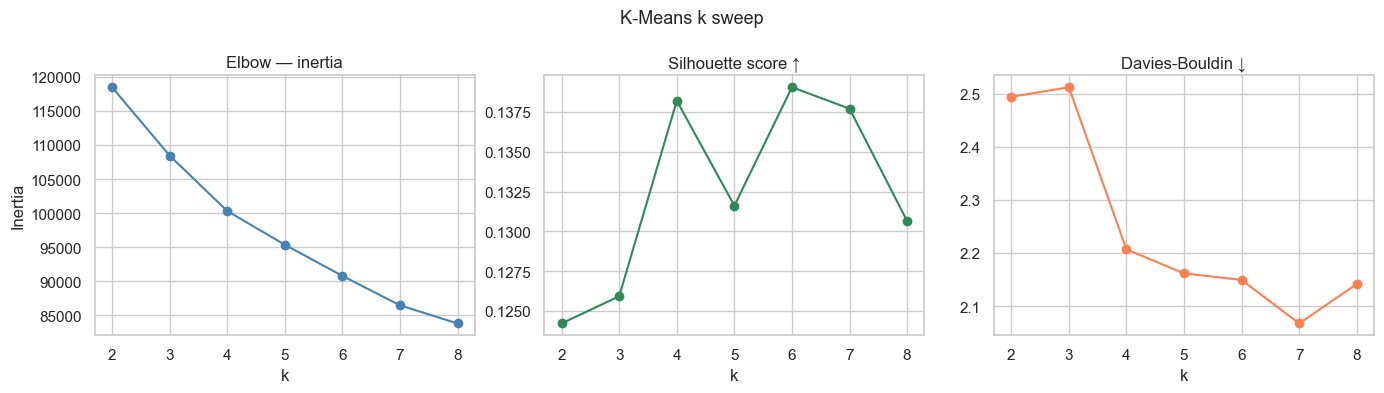

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sweep_df["k"], sweep_df["inertia"], marker="o", color="steelblue")
axes[0].set_title("Elbow — inertia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(sweep_df["k"], sweep_df["silhouette"], marker="o", color="seagreen")
axes[1].set_title("Silhouette score ↑")
axes[1].set_xlabel("k")

axes[2].plot(sweep_df["k"], sweep_df["davies_bouldin"], marker="o", color="coral")
axes[2].set_title("Davies-Bouldin ↓")
axes[2].set_xlabel("k")

plt.suptitle("K-Means k sweep", fontsize=13)
plt.tight_layout()
plt.show()

In the metrics that we used to evaluate the k-Means clusters as shown above, we find that the elbow point of the inertia plot is at k = 4. There also seems to be an absolute maximum in the silhouette score at k = 6 and an absolute minimum in the Davies-Bouldin index at k = 7, but nonetheless we choose to work with k = 4 as this provides a strong improvement in silhouette score, a substantial reduction in the Davies–Bouldin index, and we feel working with 4 clusters is more interpretable than higher values.

In [19]:
chosen_k = 4

km_final = KMeans(n_clusters=chosen_k, n_init=10, random_state=RANDOM_STATE)
train_labels = km_final.fit_predict(X_train_cluster)
test_labels = km_final.predict(X_test_cluster)

In [20]:
metrics = {
    "Silhouette ↑": silhouette_score(X_train_cluster, train_labels),
    "Davies-Bouldin ↓": davies_bouldin_score(X_train_cluster, train_labels),
    "Calinski-Harabasz ↑": calinski_harabasz_score(X_train_cluster, train_labels),
}

print(f"Final model — k = {chosen_k} (train)")
for name, val in metrics.items():
    print(f"  {name:<25s} {val:.4f}")

Final model — k = 4 (train)
  Silhouette ↑              0.1382
  Davies-Bouldin ↓          2.2069
  Calinski-Harabasz ↑       4030.5211


K-Means clustering with k = 4 captures moderate but meaningful structure in the data. The clusters are somewhat separated but not sharply distinct (low silhouette), reasonably compact and differentiated overall (high Calinski–Harabasz), and not overly overlapping (moderate Davies–Bouldin). This aligns with expectations for customer segmentation problems, where natural groupings often exist but are not entirely distinct. The clustering is still informative to support downstream analysis.

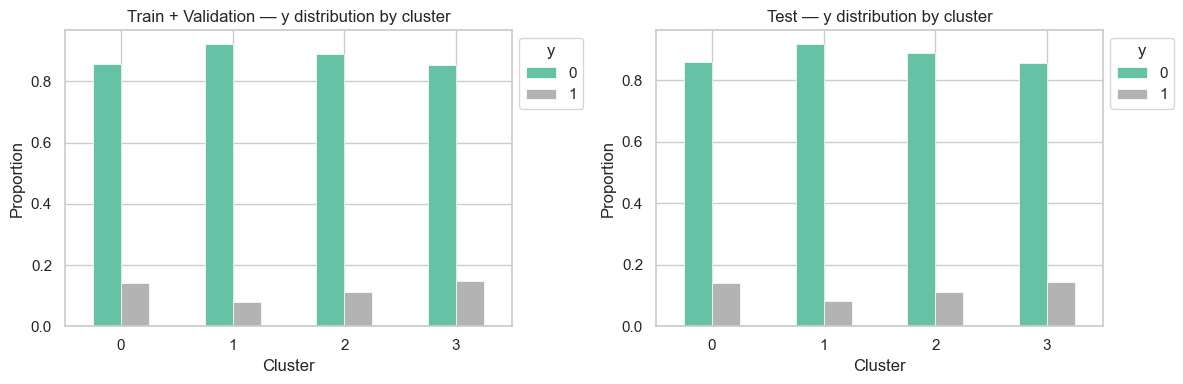

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, y, title in zip(
    axes,
    [train_labels, test_labels],
    [y_train_val, y_test],
    ["Train + Validation", "Test"],
):
    plot_df = pd.DataFrame(
        {"cluster": np.array(labels).ravel(), "y": np.array(y).ravel()}
    )

    cluster_props = (
        plot_df.groupby("cluster")["y"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    pivot = cluster_props.pivot(
        index="cluster", columns="y", values="proportion"
    ).fillna(0)

    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", linewidth=0.5)
    ax.set_title(f"{title} — y distribution by cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="y", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

While not drastically different, we do find that each cluster does seem to have a slightly different rate of succes for subscriptions to a term deposit. Also notable is that the rates for each cluster seem to be stable between the training + validation set and the test set, indicating that the differences in subscription rate is not due to overfitting and is indeed different in the underlying population representing each cluster.

In [22]:
cluster_feat = "cluster"

X_train_val_clustered = X_train_val_pre.copy()
X_train_val_clustered[cluster_feat] = train_labels
print(f"Original preprocessed train + validation: {X_train_val_pre.shape}")
print(f"Clustered preprocessed train + validation: {X_train_val_clustered.shape}")

X_test_clustered = X_test_pre.copy()
X_test_clustered[cluster_feat] = test_labels
print(f"\nOriginal preprocessed test: {X_test_pre.shape}")
print(f"Clustered preprocessed test: {X_test_clustered.shape}")

Original preprocessed train + validation: (36168, 59)
Clustered preprocessed train + validation: (36168, 60)

Original preprocessed test: (9043, 59)
Clustered preprocessed test: (9043, 60)


In [23]:
print(
    f"Train + Validation cluster counts:\n"
    f"{X_train_val_clustered[cluster_feat].value_counts(normalize=True).sort_index()}"
)

print(
    f"\nTest cluster counts:\n"
    f"{X_test_clustered[cluster_feat].value_counts(normalize=True).sort_index()}"
)

Train + Validation cluster counts:
cluster
0    0.174574
1    0.307261
2    0.242701
3    0.275464
Name: proportion, dtype: float64

Test cluster counts:
cluster
0    0.178259
1    0.306204
2    0.243393
3    0.272144
Name: proportion, dtype: float64


@MATTHEW MENTION HOW WE HAVE BALANCE IN BOTH DATASETS

We now save the preprocessed datasets

In [24]:
print(f"X train + validation preprocessed: {X_train_val_clustered.shape}")
print(f"y train + validation preprocessed: {y_train_val.shape}")
display(X_train_val_clustered.head(2))

print(f"\nX test preprocessed: {X_test_clustered.shape}")
print(f"y test preprocessed: {y_test.shape}")
display(X_test_clustered.head(2))

X train + validation preprocessed: (36168, 60)
y train + validation preprocessed: (36168, 1)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
37311,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
28102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1



X test preprocessed: (9043, 60)
y test preprocessed: (9043, 1)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
28909,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
45032,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [ ]:
nb = "02"
data_dir = Path("data")

# Train + Validation
df_path = data_dir / f"{nb}_X_train_val.parquet"
X_train_val_clustered.to_parquet(df_path, index=False)
print(f"Saved X_train_val preprocessed + clustered: {df_path}")

df_path = data_dir / f"{nb}_y_train_val.parquet"
y_train_val.to_parquet(df_path, index=False)
print(f"Saved y_train_val preprocessed + clustered: {df_path}")

# Test
df_path = data_dir / f"{nb}_X_test.parquet"
X_test_clustered.to_parquet(df_path, index=False)
print(f"\nSaved X_test preprocessed + clustered: {df_path}")

df_path = data_dir / f"{nb}_y_test.parquet"
y_test.to_parquet(df_path, index=False)
print(f"Saved y_test preprocessed + clustered: {df_path}")

Saved X_train_val: data/02_X_train_val.parquet
Saved y_train_val raw: data/02_y_train_val.parquet

Saved X_test raw: data/02_X_test.parquet
Saved y_test raw: data/02_y_test.parquet


### 5. Create datasets per cluster

Given that we now have our preprocessed and clustered data, we'll now create our train, validation and test sets for:
1. Entire dataset
2. Each cluster

These will be the datasets that we'll use during training in the following notebook

In [3]:
nb = "02"
data_dir = Path("data")

# Train + Validation
df_path = data_dir / f"{nb}_X_train_val.parquet"
X_train_val_ = pd.read_parquet(df_path)
print(f"X train + validation: {X_train_val_.shape}")

df_path = data_dir / f"{nb}_y_train_val.parquet"
y_train_val_ = pd.read_parquet(df_path)
print(f"y train + validation: {y_train_val_.shape}")

# Test
df_path = data_dir / f"{nb}_X_test.parquet"
X_test_ = pd.read_parquet(df_path)
print(f"\nX test: {X_test_.shape}")

df_path = data_dir / f"{nb}_y_test.parquet"
y_test_ = pd.read_parquet(df_path)
print(f"y test: {y_test_.shape}")

X train + validation: (36168, 60)
y train + validation: (36168, 1)

X test: (9043, 60)
y test: (9043, 1)


In [4]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val_,
    y_train_val_,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=y_train_val_,
)

print("\nX train:", X_train.shape)
assert X_train.shape[0] == y_train.shape[0]

print("X validation:", X_validation.shape)
assert X_validation.shape[0] == y_validation.shape[0]

assert X_train.shape[0] + X_validation.shape[0] == X_train_val_.shape[0]
assert y_train.shape[0] + y_validation.shape[0] == y_train_val_.shape[0]


X train: (28934, 60)
X validation: (7234, 60)


In [5]:
nb = "02"
data_dir = Path("data")

# Train
df_path = data_dir / f"{nb}_X_train.parquet"
X_train.to_parquet(df_path, index=False)
print(f"Saved X_train: {df_path}")

df_path = data_dir / f"{nb}_y_train.parquet"
y_train.to_parquet(df_path, index=False)
print(f"Saved y_train: {df_path}")

# Validation
df_path = data_dir / f"{nb}_X_validation.parquet"
X_validation.to_parquet(df_path, index=False)
print(f"Saved X_validation: {df_path}")

df_path = data_dir / f"{nb}_y_validation.parquet"
y_validation.to_parquet(df_path, index=False)
print(f"Saved y_validation: {df_path}")

Saved X_train: data/02_X_train.parquet
Saved y_train: data/02_y_train.parquet
Saved X_validation: data/02_X_validation.parquet
Saved y_validation: data/02_y_validation.parquet


We'll use these datasets for the global model (the one that includes all the segments)

#### Datasets per segment

In [6]:
nb = "02"
data_dir = Path("data")

# Load datasets
X_train = pd.read_parquet(data_dir / f"{nb}_X_train.parquet")
y_train = pd.read_parquet(data_dir / f"{nb}_y_train.parquet")

X_val = pd.read_parquet(data_dir / f"{nb}_X_validation.parquet")
y_val = pd.read_parquet(data_dir / f"{nb}_y_validation.parquet")

X_test = pd.read_parquet(data_dir / f"{nb}_X_test.parquet")
y_test = pd.read_parquet(data_dir / f"{nb}_y_test.parquet")

In [7]:
def split_and_save_by_cluster(X, y, split_name):
    print(f"{split_name}")
    for cluster_id in sorted(X["cluster"].unique()):
        mask = X["cluster"] == cluster_id

        X_subset = X.loc[mask].copy()
        y_subset = y.loc[mask].copy()

        # Drop cluster column since we don’t want it in modeling
        X_subset = X_subset.drop(columns=["cluster"])

        X_subset.to_parquet(data_dir / f"{nb}_X_{split_name}_c{cluster_id}.parquet")
        y_subset.to_parquet(data_dir / f"{nb}_y_{split_name}_c{cluster_id}.parquet")

        print(
            f"\tCluster {cluster_id}: {X_subset.shape} ({X_subset.shape[0] / X.shape[0] :.2%})"
        )

In [8]:
split_and_save_by_cluster(X_train, y_train, "train")
print("\n")
split_and_save_by_cluster(X_val, y_val, "validation")
print("\n")
split_and_save_by_cluster(X_test, y_test, "test")

train
	Cluster 0: (5043, 59) (17.43%)
	Cluster 1: (8847, 59) (30.58%)
	Cluster 2: (7058, 59) (24.39%)
	Cluster 3: (7986, 59) (27.60%)


validation
	Cluster 0: (1271, 59) (17.57%)
	Cluster 1: (2266, 59) (31.32%)
	Cluster 2: (1720, 59) (23.78%)
	Cluster 3: (1977, 59) (27.33%)


test
	Cluster 0: (1612, 59) (17.83%)
	Cluster 1: (2769, 59) (30.62%)
	Cluster 2: (2201, 59) (24.34%)
	Cluster 3: (2461, 59) (27.21%)


### 6. Inspect the transformed feature names

Retrieve the final feature names after one-hot encoding and scaling to see the exact modeling input.

In [3]:
X_train, y_train = load_dataset("02", "train")


train
X shape: (28934, 60)
y shape: (28934, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0


In [4]:
print("Number of transformed features:", len(X_train.columns))

top_feats = 30
print(f"\nFirst {top_feats} feature names:")
print(X_train.columns[:top_feats])

Number of transformed features: 60

First 30 feature names:
Index(['cat__job_admin.', 'cat__job_blue-collar', 'cat__job_entrepreneur',
       'cat__job_housemaid', 'cat__job_management', 'cat__job_retired',
       'cat__job_self-employed', 'cat__job_services', 'cat__job_student',
       'cat__job_technician', 'cat__job_unemployed', 'cat__job_unknown',
       'cat__marital_divorced', 'cat__marital_married', 'cat__marital_single',
       'cat__education_primary', 'cat__education_secondary',
       'cat__education_tertiary', 'cat__education_unknown',
       'cat__age_group_18-25', 'cat__age_group_26-35', 'cat__age_group_36-50',
       'cat__age_group_51+', 'cat__balance_bucket_high',
       'cat__balance_bucket_low', 'cat__balance_bucket_medium',
       'cat__balance_bucket_negative', 'cat__campaign_bucket_1',
       'cat__campaign_bucket_2-3', 'cat__campaign_bucket_4+'],
      dtype='object')


**Interpretation:** OHE expands the 7 categorical columns into many binary indicator columns (one per distinct category level), while the 2 numerical columns pass through with a `num__` prefix. The total of 60 processed features (vs. 21 raw inputs) is the final dimensionality that downstream models will consume.

### 7. Check the transformed data

Run a quick sanity check on the preprocessed training, validation, and test sets to confirm there are no missing or constant features.

In [5]:
X_train, y_train = load_dataset("02", "train")
X_validation, y_validation = load_dataset("02", "validation")
X_test, y_test = load_dataset("02", "test")


train
X shape: (28934, 60)
y shape: (28934, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0



validation
X shape: (7234, 60)
y shape: (7234, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0



test
X shape: (9043, 60)
y shape: (9043, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0


In [6]:
# Missing-value checks ensure preprocessing produced complete model inputs.
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_validation:", X_validation.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

# Constant columns may carry little signal for some model families.
constant_cols = [c for c in X_train.columns if X_train[c].nunique() == 1]

print("Number of constant columns:", len(constant_cols))
print(f"Constant columns: {constant_cols}")

Missing values in X_train: 0
Missing values in X_validation: 0
Missing values in X_test: 0
Number of constant columns: 0
Constant columns: []


Interpretation: Zero missing values across train, validation, and test means the preprocessing pipeline is producing complete features. If the number of constant columns is small, most transformed features retain variability and are likely informative for modeling.

We now check the datasets for each cluster

In [7]:
cluster_id = 0
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)
X_test, y_test = load_dataset(nb="02", split="test", cluster_id=cluster_id)


train | cluster 0
X shape: (5043, 59)
y shape: (5043, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0



validation | cluster 0
X shape: (1271, 59)
y shape: (1271, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0



test | cluster 0
X shape: (1612, 59)
y shape: (1612, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.469201,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [8]:
cluster_id = 1
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)
X_test, y_test = load_dataset(nb="02", split="test", cluster_id=cluster_id)


train | cluster 1
X shape: (8847, 59)
y shape: (8847, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.286185,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



validation | cluster 1
X shape: (2266, 59)
y shape: (2266, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.755682,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0



test | cluster 1
X shape: (2769, 59)
y shape: (2769, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [9]:
cluster_id = 2
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)
X_test, y_test = load_dataset(nb="02", split="test", cluster_id=cluster_id)


train | cluster 2
X shape: (7058, 59)
y shape: (7058, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
11,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



validation | cluster 2
X shape: (1720, 59)
y shape: (1720, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



test | cluster 2
X shape: (2201, 59)
y shape: (2201, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.347190,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [10]:
cluster_id = 3
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)
X_test, y_test = load_dataset(nb="02", split="test", cluster_id=cluster_id)


train | cluster 3
X shape: (7986, 59)
y shape: (7986, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.877693,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



validation | cluster 3
X shape: (1977, 59)
y shape: (1977, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



test | cluster 3
X shape: (2461, 59)
y shape: (2461, 1)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,bin__pdays_was_contacted,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.305324,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305324,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
